# Non-Stationary Spectral Simulation

This notebook implements the spectral simulation algorithm for non-stationary Gaussian random fields as described in Emery and Arroyo (2017).

## Imports and Setup

In [4]:
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

%matplotlib inline

## Simulator Class

In [1]:
class NonStationarySpectralSimulator:
    """
    Implements the spectral simulation algorithm for non-stationary Gaussian random fields
    as described in Emery and Arroyo (2017).
    """

    def __init__(self, grid_coords, config, L=5000, dim=2):
        """
        Initialize the simulator.

        Args:
            grid_coords (np.ndarray): (N, d) array of coordinates to simulate.
            config (dict): Configuration dictionary.
            L (int): Number of lines (cosine waves) to sum.
            dim (int): Spatial dimension (default 2).
        """
        self.grid = grid_coords
        self.config = config
        self.L = L
        self.d = dim
        self.num_points = grid_coords.shape[0]

    def _sample_proposal_frequencies(self, scale=3.0, nu=0.3):
        """
        Sample L frequency vectors 'u' from the proposal density 'g'.

        Uses a Multivariate T-distribution sampling method which corresponds to
        the isotropic Matern spectral density.
        """
        # Calculate alpha squared from scale and nu
        alpha_sq = (2 * nu) / (scale**2)

        # 1. Generate Z ~ N(0, I_d)
        Z = np.random.normal(0, 1, size=(self.L, self.d))

        # 2. Generate Y ~ Chi-square(2*nu)
        Y = np.random.chisquare(2 * nu, size=self.L)

        # 3. Calculate u vectors: u = Z * (alpha / sqrt(Y))
        scaling = np.sqrt(alpha_sq / Y).reshape(-1, 1)
        u_vectors = Z * scaling

        # 4. Compute g(u) values
        squared_radii = np.sum(u_vectors**2, axis=1)
        numer = gamma(nu + self.d / 2.0) * (alpha_sq**nu)
        denom = gamma(nu) * (np.pi ** (self.d / 2.0))
        constant_factor = numer / denom
        g_values = constant_factor * (alpha_sq + squared_radii) ** (-(nu + self.d / 2.0))

        return u_vectors, g_values

    def _get_local_anisotropy(self, locations):
        """
        Define the non-stationary anisotropy matrix Sigma_x for given locations.
        """
        if locations.ndim == 1:
            locations = locations[np.newaxis, :]
        N = locations.shape[0]
        mode = self.config.get("anisotropy", "linear_y")

        if mode == "lva_azimuth_ramp":
            ranges = self.config.get("ranges", [100.0, 20.0, 4.0])
            r1, r2 = ranges[0], ranges[1]
            r3 = ranges[2] if len(ranges) > 2 else 1.0
            lam1, lam2, lam3 = r1**2, r2**2, r3**2

            x_coords = locations[:, 0]
            x_min = self.config["grid"]["x_min"]
            x_max = self.config["grid"]["x_max"]
            x_norm = np.clip((x_coords - x_min) / (x_max - x_min), 0, 1)

            theta_deg_start = self.config.get('azimuth_start', 0.0)
            theta_deg_end = self.config.get('azimuth_end', 60.0)
            theta = np.deg2rad(theta_deg_start + (theta_deg_end - theta_deg_start) * x_norm)
            c, s = np.cos(theta), np.sin(theta)

            sigmas = np.zeros((N, self.d, self.d))
            sigmas[:, 0, 0] = (c**2) * lam1 + (s**2) * lam2
            sigmas[:, 0, 1] = c * s * (lam1 - lam2)
            sigmas[:, 1, 0] = sigmas[:, 0, 1]
            sigmas[:, 1, 1] = (s**2) * lam1 + (c**2) * lam2

            if self.d == 3:
                sigmas[:, 2, 2] = lam3
            return sigmas
        else:
            if self.d >= 2:
                y_coords = locations[:, 1]
            else:
                y_coords = np.zeros(N)
            min_range, max_range, max_grid_y = 5.0, 30.0, 200.0
            clamped_y = np.clip(y_coords, 0, max_grid_y)
            range_vals = min_range + (max_range - min_range) * (clamped_y / max_grid_y)
            sigmas = np.zeros((N, self.d, self.d))
            idx = np.arange(self.d)
            sigmas[:, idx, idx] = (range_vals**2)[:, np.newaxis]
            return sigmas

    def simulate_univariate_gaussian(self, batch_size=1000):
        start_time = time.time()
        local_sigmas = self._get_local_anisotropy(self.grid)
        u_vectors, g_vals = self._sample_proposal_frequencies()
        phases = np.random.uniform(0, 2 * np.pi, self.L)
        field = np.zeros(self.num_points)

        for i in range(0, self.L, batch_size):
            end = min(i + batch_size, self.L)
            u_batch, phi_batch, g_batch = u_vectors[i:end], phases[i:end], g_vals[i:end]
            dot_prods = np.dot(self.grid, u_batch.T)
            u_sigma_u = np.einsum("bj,njk,bk->nb", u_batch, local_sigmas, u_batch)
            det_sigmas = np.linalg.det(local_sigmas)
            constant_factor = (det_sigmas[:, np.newaxis]**0.5) * ((2 * np.sqrt(np.pi)) ** (-self.d))
            f_x_vals = constant_factor * np.exp(-0.25 * u_sigma_u)
            weights = np.sqrt(2 * f_x_vals / g_batch[np.newaxis, :])
            field += np.sum(weights * np.cos(dot_prods + phi_batch[np.newaxis, :]), axis=1)

        print(f"Simulation completed in {time.time() - start_time:.2f} seconds.")
        return field / np.sqrt(self.L)

    def simulate_univariate_matern(self, nu_local=0.5, batch_size=1000):
        start_time = time.time()
        local_sigmas = self._get_local_anisotropy(self.grid)
        u_vectors, g_vals = self._sample_proposal_frequencies()
        phases = np.random.uniform(0, 2 * np.pi, self.L)
        field = np.zeros(self.num_points)

        for i in range(0, self.L, batch_size):
            end = min(i + batch_size, self.L)
            u_batch, phi_batch, g_batch = u_vectors[i:end], phases[i:end], g_vals[i:end]
            a_batch = np.random.exponential(1, size=(end - i))
            dot_prods = np.dot(self.grid, u_batch.T)
            u_sigma_u = np.einsum("bj,njk,bk->nb", u_batch, local_sigmas, u_batch)
            det_sigmas = np.linalg.det(local_sigmas)
            scale_factor_b = (4 * a_batch)[np.newaxis, :]
            det_effective = (scale_factor_b**self.d) * det_sigmas[:, np.newaxis]
            u_eff_sigma_u = scale_factor_b * u_sigma_u
            constant_factor = (det_effective**0.5) * ((2 * np.sqrt(np.pi)) ** (-self.d))
            f_x_vals = constant_factor * np.exp(-0.25 * u_eff_sigma_u)
            weights = np.sqrt(2 * f_x_vals / g_batch[np.newaxis, :])
            weights *= ((a_batch ** (nu_local - 1)) / gamma(nu_local))[np.newaxis, :]
            field += np.sum(weights * np.cos(dot_prods + phi_batch[np.newaxis, :]), axis=1)

        print(f"Simulation completed in {time.time() - start_time:.2f} seconds.")
        return field / np.sqrt(self.L)

## Helper Function for Running and Plotting

In [2]:
def run_and_plot(config):
    grid_cfg = config["grid"]
    x_range = np.linspace(grid_cfg["x_min"], grid_cfg["x_max"], grid_cfg["x_n"])
    y_range = np.linspace(grid_cfg["y_min"], grid_cfg["y_max"], grid_cfg["y_n"])

    if "z_min" in grid_cfg:
        z_range = np.linspace(grid_cfg["z_min"], grid_cfg["z_max"], grid_cfg["z_n"])
        xv, yv, zv = np.meshgrid(x_range, y_range, z_range, indexing="ij")
        grid_coords = np.column_stack([xv.ravel(), yv.ravel(), zv.ravel()])
        dim = 3
    else:
        xv, yv = np.meshgrid(x_range, y_range, indexing="ij")
        grid_coords = np.column_stack([xv.ravel(), yv.ravel()])
        dim = 2

    sim = NonStationarySpectralSimulator(grid_coords, config, L=config.get("L", 5000), dim=dim)
    sim_type = config.get("type", "gaussian").lower()
    
    if sim_type == "gaussian":
        result = sim.simulate_univariate_gaussian(batch_size=config.get("batch_size", 1000))
        title = "Gaussian Field"
    else:
        nu = config.get("matern_nu", 0.5)
        result = sim.simulate_univariate_matern(nu_local=nu, batch_size=config.get("batch_size", 1000))
        title = f"Matern Field (nu={nu})"

    plt.figure(figsize=(10, 8))
    if dim == 2:
        plt.imshow(result.reshape(grid_cfg["x_n"], grid_cfg["y_n"]).T, origin="lower",
                   extent=[grid_cfg["x_min"], grid_cfg["x_max"], grid_cfg["y_min"], grid_cfg["y_max"]])
    else:
        mid_z_idx = grid_cfg["z_n"] // 2
        slice_data = result.reshape(grid_cfg["x_n"], grid_cfg["y_n"], grid_cfg["z_n"])[:, :, mid_z_idx]
        plt.imshow(slice_data.T, origin="lower",
                   extent=[grid_cfg["x_min"], grid_cfg["x_max"], grid_cfg["y_min"], grid_cfg["y_max"]])
        title += f" (Z slice {mid_z_idx})"
    
    plt.title(title)
    plt.colorbar(label="Field Value")
    plt.show()

## Examples

### 1. Isotropic 2D GRF with variable correlation range

Simulation completed in 1.16 seconds.


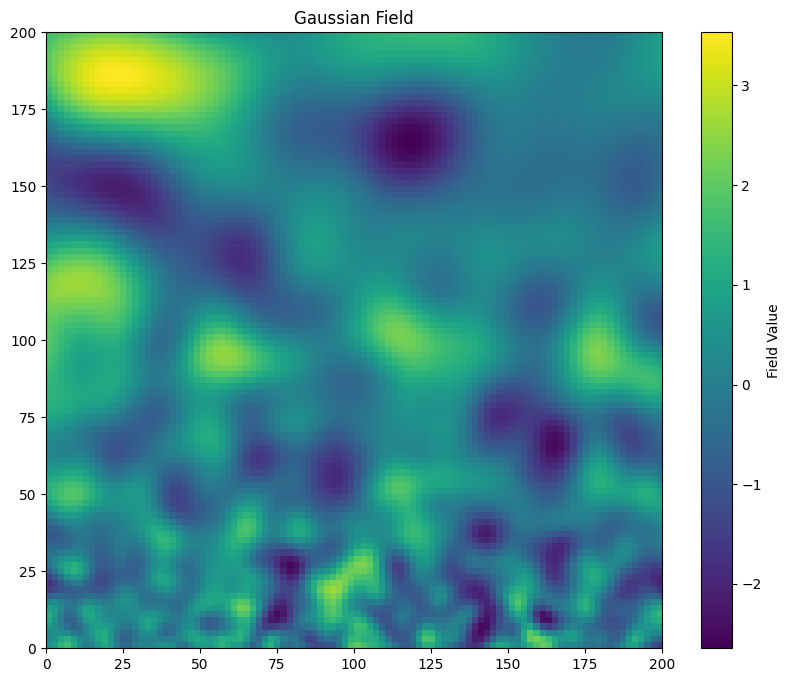

In [5]:
config_2d = {
    "grid": {"x_min": 0, "x_max": 200, "x_n": 100, "y_min": 0, "y_max": 200, "y_n": 100},
    "L": 2000, "batch_size": 500, "type": "gaussian"
}
run_and_plot(config_2d)

### 2. Anisotropic 2D GRF with varying azimuth

Simulation completed in 1.79 seconds.


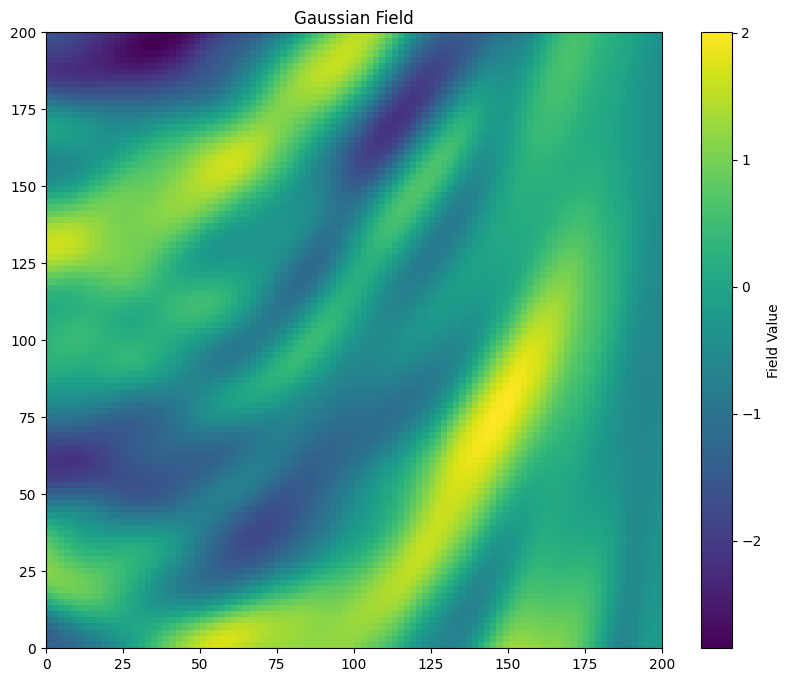

In [6]:
config_lva = {
    "grid": {"x_min": 0, "x_max": 200, "x_n": 100, "y_min": 0, "y_max": 200, "y_n": 100},
    "L": 3000, "batch_size": 600, "type": "gaussian",
    "anisotropy": "lva_azimuth_ramp", "azimuth_start": 0.0, "azimuth_end": 80.0,
    "ranges": [150.0, 18.0]
}
run_and_plot(config_lva)